In [1]:
import pandas as pd
import numpy as np

In [52]:
df=pd.read_csv('weatherAUS.csv')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [53]:
df.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [54]:
df=df.fillna(df.mean(numeric_only=True))
df=df.fillna(df.mode(numeric_only=False).iloc[0])
df.isna().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [83]:
# 1. Define your categorical columns
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

# 2. Convert them into "dummy" (one-hot) variables
# drop_first=True helps avoid the "Dummy Variable Trap" (mathematical redundancy)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Pressure9am'] = df['Pressure9am'].fillna(df['Pressure9am'].mean())
df['Pressure3pm'] = df['Pressure3pm'].fillna(df['Pressure3pm'].mean())
df['Temp9am'] = df['Temp9am'].fillna(df['Temp9am'].mean())
df['Temp3pm'] = df['Temp3pm'].fillna(df['Temp3pm'].mean())

# --- STEP 2: FEATURE ENGINEERING (Put it here!) ---
df['Pressure_Change'] = df['Pressure3pm'] - df['Pressure9am']
df['Temp_Change'] = df['Temp3pm'] - df['Temp9am']
# Convert categorical to dummy variables
# drop_first=True prevents multicollinearity (the Dummy Variable Trap)
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Important: Convert Boolean (True/False) to Integers (1/0) 
# Newer versions of pandas return True/False, which can break some manual math
df_final = df_final.astype({col: int for col in df_final.columns if df_final[col].dtype == 'bool'})
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Check the new columns
print(df_final.columns)

Index(['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       ...
       'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE', 'WindDir3pm_SSE',
       'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W', 'WindDir3pm_WNW',
       'WindDir3pm_WSW', 'RainToday_Yes'],
      dtype='object', length=114)


In [84]:
#shuffling to make sure that the split is random and not biased
df_shuffled=df_final.sample(frac=1, random_state=42).reset_index(drop=True)
# frac gives back all the data , random makes sure that the order in which its getting randomised is the same
split=0.8
n=int(len(df_shuffled)*split)
train=df_shuffled.iloc[:n]
test=df_shuffled.iloc[n:]
X_train=train.drop(['RainTomorrow','Date'], axis=1)
y_train=train['RainTomorrow']

X_test=test.drop('RainTomorrow', axis=1)
y_test=test['RainTomorrow']

print('total rows:',len(df))
print('Train rows:',len(X_train))
print('Test rows:',len(X_test))

total rows: 145460
Train rows: 116368
Test rows: 29092


In [85]:
#Min-Max Scaling
num_cols=X_train.select_dtypes(include=['number']).columns # selecting only numeric columns
X_train_scaled=(X_train[num_cols]-X_train[num_cols].min())/(X_train[num_cols].max()-X_train[num_cols].min())
X_test_scaled=(X_test[num_cols]-X_train[num_cols].min())/(X_train[num_cols].max()-X_train[num_cols].min()) 
#to prevent data leakage we use train max and min values

In [86]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

feature=X_train_scaled.shape[1]
w=np.zeros(feature)
b=0

In [87]:
#gradient descent
iter=1000
alpha=0.5
# Convert the target variable to numbers
# 'Yes' becomes 1, 'No' becomes 0
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

# It is also safer to convert them to numpy arrays to avoid pandas indexing issues in the loop
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

#if this shows any error its prolly because the numpy array lost its pandas properties as map is a function in pandas so the 
#remedy is going back to the line where i declared the test and train set and re running it

costs=[] #for the cost function
n=len(y_train)

for i in range(iter):
    z=np.dot(X_train_scaled ,w)+b
    predict=sigmoid(z)
    error=predict-y_train

    loss = (-1/n) * np.sum(y_train * np.log(predict + 1e-15) + (1 - y_train) * np.log(1 - predict + 1e-15))
    #this is our loss function which we calculate for each property
    costs.append(loss)
    
    dw = (1 / len(y_train)) * np.dot(X_train_scaled.T, error)
    db = (1 / len(y_train)) * np.sum(error)

    w-=alpha*dw
    b-=alpha*db

    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {loss}")

Iteration 0: Cost = 0.6931471805599434
Iteration 100: Cost = 0.429119185380657
Iteration 200: Cost = 0.40387300951812977
Iteration 300: Cost = 0.3929273640699971
Iteration 400: Cost = 0.386820852586936
Iteration 500: Cost = 0.3829733119168762
Iteration 600: Cost = 0.38037000110555036
Iteration 700: Cost = 0.37851677120201016
Iteration 800: Cost = 0.37714122364918345
Iteration 900: Cost = 0.37608160183133493


In [88]:
# Probability on test data
z_test = np.dot(X_test_scaled, w) + b
test_probs = sigmoid(z_test)

# Convert to 0 or 1
y_final_pred = [1 if p >= 0.3 else 0 for p in test_probs]

In [89]:
correct_guesses = sum(y_final_pred == y_test)
accuracy = (correct_guesses / len(y_test)) * 100
print(f"Manual Logistic Regression Accuracy: {accuracy}%")

Manual Logistic Regression Accuracy: 80.69916128145195%


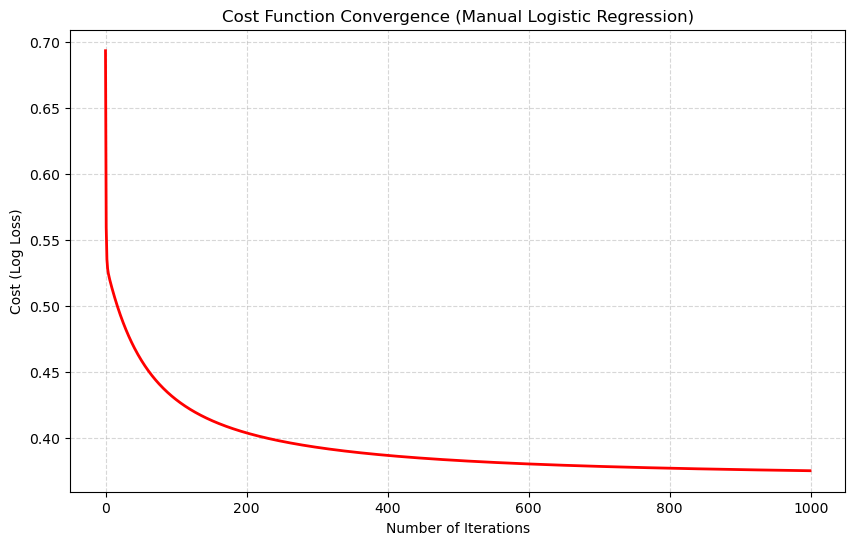

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(costs, color='red', linewidth=2)
plt.title("Cost Function Convergence (Manual Logistic Regression)")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (Log Loss)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

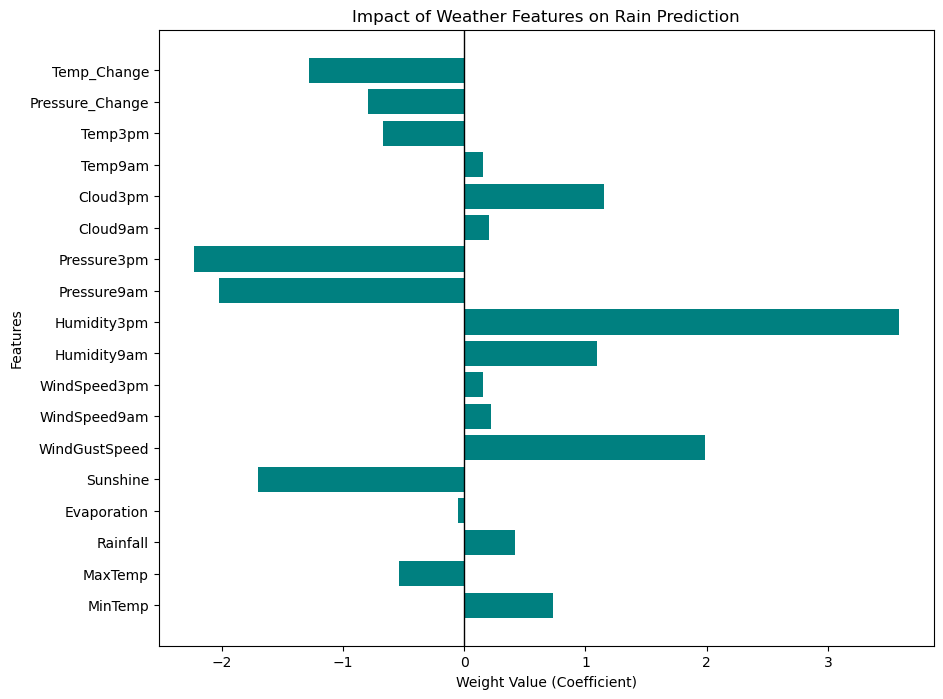

In [91]:
# Assuming X_train_scaled still has the column names from your numeric split
features = X_train_scaled.columns

plt.figure(figsize=(10, 8))
plt.barh(features, w, color='teal')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title("Impact of Weather Features on Rain Prediction")
plt.xlabel("Weight Value (Coefficient)")
plt.ylabel("Features")
plt.show()

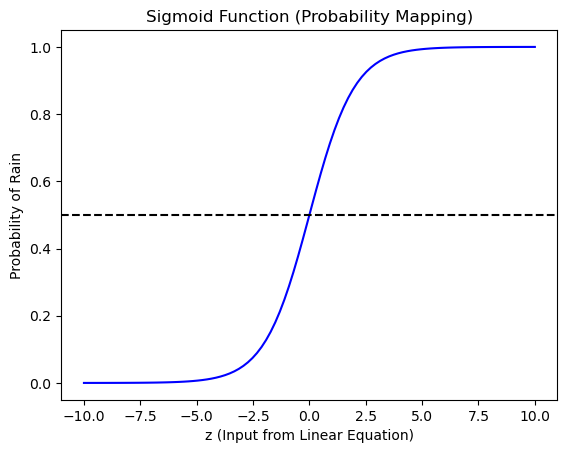

In [92]:
z_values = np.linspace(-10, 10, 100)
probabilities = sigmoid(z_values)

plt.plot(z_values, probabilities, color='blue')
plt.axhline(y=0.5, color='black', linestyle='--') # Decision Boundary
plt.title("Sigmoid Function (Probability Mapping)")
plt.xlabel("z (Input from Linear Equation)")
plt.ylabel("Probability of Rain")
plt.show()

In [93]:
# Convert lists/arrays to numpy for comparison
y_test = np.array(y_test)
y_pred = np.array(y_final_pred)

# 1. Calculate components
tp = np.sum((y_pred == 1) & (y_test == 1)) # True Positives
fp = np.sum((y_pred == 1) & (y_test == 0)) # False Positives
fn = np.sum((y_pred == 0) & (y_test == 1)) # False Negatives

# 2. Calculate Precision and Recall
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# 3. Calculate F1 Score
if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.5488
Recall: 0.6551
F1 Score: 0.5972


In [94]:
y_pred.sum()

np.int64(7586)